# Multi-Dataset Insurance Benchmark: TabPFN vs GLM

Runs the same TabPFN vs GLM comparison across **four public insurance classification datasets**
to assess whether TabPFN v2.6 consistently outperforms (or trails) a tuned logistic regression.

## Datasets

| # | Dataset | Source | Rows | Features | Target | Positive Rate |
|---|---------|--------|------|----------|--------|---------------|
| 1 | `eudirectlapse` | CASdatasets (EU direct insurer) | 23,060 | 18 | lapse | 12.8% |
| 2 | `coil2000` | OpenML ID 298 (Dutch insurance) | 9,822 | 85 | CARAVAN | 6.0% |
| 3 | `ausprivauto0405` | CASdatasets (AU vehicle, 2004–05) | 67,856 | 6 | ClaimOcc | 6.8% |
| 4 | `freMTPL2freq_binary` | CASdatasets FR MTPL (sampled 50K) | 50,000 | 10 | ClaimIndicator | 5.0% |

## Design

- All models train on **at most 10,000 samples** (stratified) for a fair apples-to-apples comparison.
- Test set: 20% hold-out (stratified).
- Models: `LogisticRegression` (GLM baseline), `TabPFN` (client), `CatBoost`, `RandomForest`, `XGBoost`.
- Metrics: **ROC AUC** and **PR AUC** (area under precision-recall curve).
- `tabpfn_client` backend is used (cloud inference).

In [3]:
# =========================================================================
# IMPORTS
# =========================================================================
import sys, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.utils.class_weight import compute_class_weight

from catboost import CatBoostClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

# paths
REPO_ROOT = Path('../../')
DATA_DIR  = REPO_ROOT / 'data' / 'raw'
OUT_DIR   = REPO_ROOT / 'data' / 'processed'
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED     = 42
GLOBAL_MAX_TRAIN = 10_000   # cap for ALL models (fair comparison)
MAX_PRED_BATCH   = 10_000   # tabpfn_client predict limit per call
TEST_SIZE        = 0.20

print('Data dir:', DATA_DIR.resolve())
print('Files:', sorted(p.name for p in DATA_DIR.iterdir()))

Data dir: /Users/Scott/Documents/Data Science/ADSWP/TabPFN-work-scott/data/raw
Files: ['ausprivauto0405.csv', 'coil2000.csv', 'eudirectlapse.csv', 'freMTPL2freq.csv', 'freMTPL2freq_binary.csv']


In [8]:
# =========================================================================
# BACKEND SELECTION  (cell identical to notebook 02)
# =========================================================================
from IPython.display import Markdown, display

# --- Detect environment ---
try:
    import google.colab  # type: ignore
    env = 'colab'
except ImportError:
    env = 'local'

# --- Select backend ---
backend = 'client'   # ← 'client' uses tabpfn_client cloud API

if backend == 'local':
    from tabpfn import TabPFNClassifier
    display(Markdown('**Backend:** `tabpfn` local'))
elif backend == 'client':
    import tabpfn_client
    from tabpfn_client import TabPFNClassifier, init
    try:
        init(use_server=True)
        display(Markdown('**Backend:** `tabpfn_client` (cloud API) — authenticated ✅'))
    except Exception as e:
        display(Markdown(f'⚠️  tabpfn_client init: {e}'))
else:
    raise ValueError(f"Unknown backend: {backend!r}")

print(f'backend={backend!r}  env={env!r}')

########  ########   ###  #########  #########       ###         #####     ########  ########
     ###        ##   ###  ###   ###        ###       ###        ###  ###   ##   ###  ###     
########  #######    ###  ###   ###  #######         ###        ########   ######    ########
###       ###   ##   ###  ###   ###  ###   ###       ###        ###  ###   ##   ###       ###
###       ###   ##   ###  #########  ###   ###       ########   ###  ###   ########  ########                      

Thanks for being part of the journey

TabPFN is under active development, please help us improve and report any bugs/ideas you find.

Report issues: https://github.com/priorlabs/tabpfn-client/issues

Press Ctrl+C anytime to exit


Opening browser for login. Please complete the login/registration process in your browser and return here.



Interrupted. Goodbye!

**Backend:** `tabpfn_client` (cloud API) — authenticated ✅

backend='client'  env='local'


In [9]:
# =========================================================================
# DATASET REGISTRY
# =========================================================================
# Each entry: (csv_name, target_column, display_name)
DATASETS = [
    ('eudirectlapse.csv',       'lapse',           'EU Direct Lapse'),
    ('coil2000.csv',            'CARAVAN',         'COIL 2000 (NL)'),
    ('ausprivauto0405.csv',     'ClaimOcc',        'Aus. Vehicle (AU)'),
    ('freMTPL2freq_binary.csv', 'ClaimIndicator',  'freMTPL2 Binary (FR)'),
]

# Verify all files exist
for fname, _, label in DATASETS:
    p = DATA_DIR / fname
    if p.exists():
        print(f'  ✅ {label:<25} {fname}')
    else:
        print(f'  ❌ {label:<25} {fname} — NOT FOUND. Run: python scripts/download_datasets.py')

  ✅ EU Direct Lapse           eudirectlapse.csv
  ✅ COIL 2000 (NL)            coil2000.csv
  ✅ Aus. Vehicle (AU)         ausprivauto0405.csv
  ✅ freMTPL2 Binary (FR)      freMTPL2freq_binary.csv


In [10]:
# =========================================================================
# PREPROCESSING HELPER
# =========================================================================
def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    """Auto-detect numeric/categorical columns and build a ColumnTransformer."""
    num_cols = X.select_dtypes(include=['number']).columns.tolist()
    cat_cols = X.select_dtypes(exclude=['number']).columns.tolist()

    transformers = []
    if num_cols:
        transformers.append(('num', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('scl', StandardScaler()),
        ]), num_cols))
    if cat_cols:
        transformers.append(('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
        ]), cat_cols))

    return ColumnTransformer(transformers, remainder='drop')


def build_tabpfn_features(X: pd.DataFrame) -> np.ndarray:
    """Encode X for TabPFN: ordinal-encode categoricals, impute nums, NO scaling."""
    num_cols = X.select_dtypes(include=['number']).columns.tolist()
    cat_cols = X.select_dtypes(exclude=['number']).columns.tolist()

    transformers = []
    if num_cols:
        transformers.append(('num', SimpleImputer(strategy='median'), num_cols))
    if cat_cols:
        transformers.append(('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
        ]), cat_cols))

    ct = ColumnTransformer(transformers, remainder='drop')
    return ct


def tabpfn_predict_proba_batched(model, X, batch_size=MAX_PRED_BATCH):
    """tabpfn_client enforces <=10k rows per predict call; batch if needed."""
    n = X.shape[0]
    if n <= batch_size:
        return model.predict_proba(X)[:, 1]

    parts = []
    for i in range(0, n, batch_size):
        parts.append(model.predict_proba(X[i:i+batch_size])[:, 1])
    return np.concatenate(parts)


print('Preprocessing helpers defined ✅')

Preprocessing helpers defined ✅


In [11]:
# =========================================================================
# BENCHMARK LOOP
# Results stored in `all_results` list of dicts.
# =========================================================================
all_results = []
dataset_meta = []

for fname, target_col, label in DATASETS:
    print(f'\n{"="*60}')
    print(f'Dataset: {label}  ({fname})')
    print('='*60)

    # ------------------------------------------------------------------
    # 1. Load
    # ------------------------------------------------------------------
    df = pd.read_csv(DATA_DIR / fname)
    X_full = df.drop(columns=[target_col])
    y_full = df[target_col].astype(int)

    pos_rate = y_full.mean()
    print(f'  Rows: {len(df):,}  Features: {X_full.shape[1]}  +rate: {pos_rate:.1%}')
    dataset_meta.append({'name': label, 'rows': len(df), 'features': X_full.shape[1],
                         'positive_rate': pos_rate})

    # ------------------------------------------------------------------
    # 2. Train/test split
    # ------------------------------------------------------------------
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_full, y_full, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_full)

    # Cap training set (stratified)
    if len(X_tr) > GLOBAL_MAX_TRAIN:
        X_tr, _, y_tr, _ = train_test_split(
            X_tr, y_tr, train_size=GLOBAL_MAX_TRAIN,
            random_state=RANDOM_SEED, stratify=y_tr)

    print(f'  Train: {len(X_tr):,}  Test: {len(X_te):,}')

    # Class weights (for sklearn models)
    cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_tr.values)
    cw_dict = {0: cw[0], 1: cw[1]}

    # ------------------------------------------------------------------
    # 3. Preprocessors
    # ------------------------------------------------------------------
    prep_skl = build_preprocessor(X_tr)      # scaled — for LogReg/RF
    prep_tab = build_tabpfn_features(X_tr)   # unscaled — for TabPFN

    X_tr_skl = prep_skl.fit_transform(X_tr)
    X_te_skl = prep_skl.transform(X_te)

    X_tr_tab = prep_tab.fit_transform(X_tr)
    X_te_tab = prep_tab.transform(X_te)

    y_tr_arr = y_tr.values
    y_te_arr = y_te.values

    # ------------------------------------------------------------------
    # 4. Model definitions
    # ------------------------------------------------------------------
    sklearn_models = {
        'LogisticRegression (GLM)': LogisticRegression(
            max_iter=1000, class_weight='balanced', random_state=RANDOM_SEED),
        'RandomForest': RandomForestClassifier(
            n_estimators=200, class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1),
        'CatBoost': CatBoostClassifier(
            iterations=300, learning_rate=0.05, depth=6,
            class_weights=cw_dict, random_seed=RANDOM_SEED, verbose=0),
        'XGBoost': XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            scale_pos_weight=cw_dict[1] / cw_dict[0],
            random_state=RANDOM_SEED, eval_metric='logloss', verbosity=0),
    }

    # ------------------------------------------------------------------
    # 5. Train & evaluate each model
    # ------------------------------------------------------------------
    for mname, mdl in sklearn_models.items():
        t0 = time.time()
        mdl.fit(X_tr_skl, y_tr_arr)
        proba = mdl.predict_proba(X_te_skl)[:, 1]
        elapsed = time.time() - t0
        roc = roc_auc_score(y_te_arr, proba)
        pr  = average_precision_score(y_te_arr, proba)
        all_results.append({'dataset': label, 'model': mname,
                             'roc_auc': roc, 'pr_auc': pr, 'time_s': elapsed})
        print(f'  {mname:<30} ROC={roc:.4f}  PR={pr:.4f}  ({elapsed:.1f}s)')

    # TabPFN
    print(f'  TabPFN (client) running…')
    t0 = time.time()
    if backend == 'local':
        tab = TabPFNClassifier(n_estimators=8, device='auto', random_state=RANDOM_SEED)
    else:
        tab = TabPFNClassifier(random_state=RANDOM_SEED)
    tab.fit(X_tr_tab, y_tr_arr)
    proba_tab = tabpfn_predict_proba_batched(tab, X_te_tab)
    elapsed = time.time() - t0
    roc_tab = roc_auc_score(y_te_arr, proba_tab)
    pr_tab  = average_precision_score(y_te_arr, proba_tab)
    all_results.append({'dataset': label, 'model': 'TabPFN',
                        'roc_auc': roc_tab, 'pr_auc': pr_tab, 'time_s': elapsed})
    print(f'  {"TabPFN":<30} ROC={roc_tab:.4f}  PR={pr_tab:.4f}  ({elapsed:.1f}s)')

print('\n✅ All benchmarks complete.')


Dataset: EU Direct Lapse  (eudirectlapse.csv)
  Rows: 23,060  Features: 18  +rate: 12.8%
  Train: 10,000  Test: 4,612
  LogisticRegression (GLM)       ROC=0.5943  PR=0.1688  (0.3s)
  RandomForest                   ROC=0.5765  PR=0.1650  (1.6s)
  CatBoost                       ROC=0.5897  PR=0.1739  (1.7s)
  XGBoost                        ROC=0.5697  PR=0.1624  (0.6s)
  TabPFN (client) running…


########  ########   ###  #########  #########       ###         #####     ########  ########
     ###        ##   ###  ###   ###        ###       ###        ###  ###   ##   ###  ###     
########  #######    ###  ###   ###  #######         ###        ########   ######    ########
###       ###   ##   ###  ###   ###  ###   ###       ###        ###  ###   ##   ###       ###
###       ###   ##   ###  #########  ###   ###       ########   ###  ###   ########  ########                      

Thanks for being part of the journey

TabPFN is under active development, please help us improve and report any bugs/ideas you find.

Report issues: https://github.com/priorlabs/tabpfn-client/issues

...

  TabPFN                         ROC=0.7372  PR=0.1404  (8.9s)

Dataset: Aus. Vehicle (AU)  (ausprivauto0405.csv)
  Rows: 67,856  Features: 6  +rate: 6.8%
  Train: 10,000  Test: 13,572
  LogisticRegression (GLM)       ROC=0.6587  PR=0.1063  (0.0s)
  RandomForest                   ROC=0.5902  PR=0.0871  (0.7s)
  CatBoost                       ROC=0.6309  PR=0.0986  (1.0s)
  XGBoost                        ROC=0.6117  PR=0.0952  (0.5s)
  TabPFN (client) running…


Processing: 100%|██████████| [00:02<00:00]
Processing: 100%|██████████| [00:01<00:00]


  TabPFN                         ROC=0.6628  PR=0.1079  (8.4s)

Dataset: freMTPL2 Binary (FR)  (freMTPL2freq_binary.csv)
  Rows: 50,000  Features: 10  +rate: 5.0%
  Train: 10,000  Test: 10,000
  LogisticRegression (GLM)       ROC=0.5981  PR=0.0730  (0.0s)
  RandomForest                   ROC=0.6117  PR=0.0761  (0.7s)
  CatBoost                       ROC=0.6158  PR=0.0877  (1.1s)
  XGBoost                        ROC=0.6078  PR=0.0828  (0.6s)
  TabPFN (client) running…


Processing: 100%|██████████| [00:02<00:00]

  TabPFN                         ROC=0.6430  PR=0.0913  (5.2s)

✅ All benchmarks complete.


In [12]:
# =========================================================================
# RESULTS: Summary Table
# =========================================================================
from IPython.display import display, Markdown

results_df = pd.DataFrame(all_results)

# Pivot to wide format: rows=dataset, columns=model, values=ROC AUC
pivot_roc = results_df.pivot(index='dataset', columns='model', values='roc_auc').round(4)
pivot_pr  = results_df.pivot(index='dataset', columns='model', values='pr_auc').round(4)

# Preserve natural dataset order
ordered_datasets = [label for _, _, label in DATASETS]
pivot_roc = pivot_roc.reindex(ordered_datasets)
pivot_pr  = pivot_pr.reindex(ordered_datasets)

# Bold the best model per row
def highlight_max(row):
    best = row.max()
    return ['font-weight: bold; color: darkgreen' if v == best else '' for v in row]

display(Markdown('## ROC AUC by Dataset and Model'))
display(pivot_roc.style.apply(highlight_max, axis=1).format('{:.4f}'))

display(Markdown('## PR AUC by Dataset and Model'))
display(pivot_pr.style.apply(highlight_max, axis=1).format('{:.4f}'))

# Rank TabPFN vs GLM directly
display(Markdown('## TabPFN vs GLM (LogisticRegression) head-to-head'))
glm_col = 'LogisticRegression (GLM)'
tab_col = 'TabPFN'

vs_roc = results_df[results_df['model'].isin([glm_col, tab_col])].copy()
vs_roc = vs_roc.pivot(index='dataset', columns='model', values='roc_auc').round(4)
vs_roc = vs_roc.reindex(ordered_datasets)
vs_roc['TabPFN_wins_ROC'] = vs_roc[tab_col] > vs_roc[glm_col]
vs_roc['delta_roc_auc'] = (vs_roc[tab_col] - vs_roc[glm_col]).round(4)
display(vs_roc)

vs_pr = results_df[results_df['model'].isin([glm_col, tab_col])].copy()
vs_pr = vs_pr.pivot(index='dataset', columns='model', values='pr_auc').round(4)
vs_pr = vs_pr.reindex(ordered_datasets)
vs_pr['TabPFN_wins_PR'] = vs_pr[tab_col] > vs_pr[glm_col]
vs_pr['delta_pr_auc'] = (vs_pr[tab_col] - vs_pr[glm_col]).round(4)

roc_wins = int(vs_roc['TabPFN_wins_ROC'].sum())
pr_wins = int(vs_pr['TabPFN_wins_PR'].sum())
total = len(vs_roc)
mean_delta_roc = vs_roc['delta_roc_auc'].mean()
median_delta_roc = vs_roc['delta_roc_auc'].median()
mean_delta_pr = vs_pr['delta_pr_auc'].mean()
median_delta_pr = vs_pr['delta_pr_auc'].median()

display(Markdown('## Compact Summary'))
display(Markdown(
    f'- ROC wins (TabPFN over GLM): **{roc_wins}/{total}**\n'
    f'- PR wins (TabPFN over GLM): **{pr_wins}/{total}**\n'
    f'- Mean delta ROC AUC (TabPFN - GLM): **{mean_delta_roc:+.4f}**\n'
    f'- Median delta ROC AUC (TabPFN - GLM): **{median_delta_roc:+.4f}**\n'
    f'- Mean delta PR AUC (TabPFN - GLM): **{mean_delta_pr:+.4f}**\n'
    f'- Median delta PR AUC (TabPFN - GLM): **{median_delta_pr:+.4f}**'
))

## ROC AUC by Dataset and Model

model,CatBoost,LogisticRegression (GLM),RandomForest,TabPFN,XGBoost
dataset,,,,,
EU Direct Lapse,0.5897,0.5943,0.5765,0.6073,0.5697
COIL 2000 (NL),0.6898,0.6956,0.6612,0.7372,0.6841
Aus. Vehicle (AU),0.6309,0.6587,0.5902,0.6628,0.6117
freMTPL2 Binary (FR),0.6158,0.5981,0.6117,0.6430,0.6078


## PR AUC by Dataset and Model

model,CatBoost,LogisticRegression (GLM),RandomForest,TabPFN,XGBoost
dataset,,,,,
EU Direct Lapse,0.1739,0.1688,0.1650,0.1876,0.1624
COIL 2000 (NL),0.1153,0.1332,0.1145,0.1404,0.1101
Aus. Vehicle (AU),0.0986,0.1063,0.0871,0.1079,0.0952
freMTPL2 Binary (FR),0.0877,0.0730,0.0761,0.0913,0.0828


## TabPFN vs GLM (LogisticRegression) head-to-head

model,LogisticRegression (GLM),TabPFN,TabPFN_wins_ROC,delta_roc_auc
dataset,,,,
EU Direct Lapse,0.5943,0.6073,True,0.0130
COIL 2000 (NL),0.6956,0.7372,True,0.0416
Aus. Vehicle (AU),0.6587,0.6628,True,0.0041
freMTPL2 Binary (FR),0.5981,0.6430,True,0.0449


## Compact Summary

- ROC wins (TabPFN over GLM): **4/4**
- PR wins (TabPFN over GLM): **4/4**
- Mean delta ROC AUC (TabPFN - GLM): **+0.0259**
- Median delta ROC AUC (TabPFN - GLM): **+0.0273**
- Mean delta PR AUC (TabPFN - GLM): **+0.0115**
- Median delta PR AUC (TabPFN - GLM): **+0.0128**

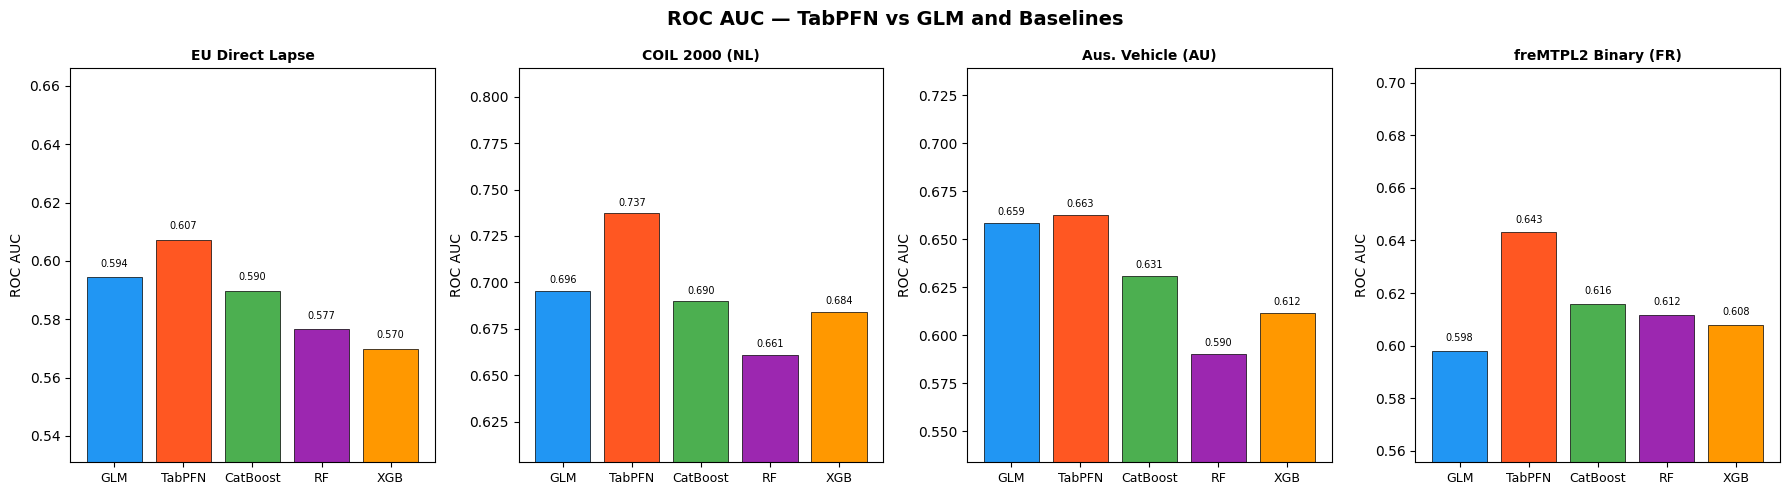

Figure saved.


In [13]:
# =========================================================================
# VISUALISATION: bar chart of ROC AUC across datasets
# =========================================================================
model_order = ['LogisticRegression (GLM)', 'TabPFN', 'CatBoost', 'RandomForest', 'XGBoost']
colors      = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=False)
fig.suptitle('ROC AUC — TabPFN vs GLM and Baselines', fontsize=14, fontweight='bold')

for ax, (fname, target_col, label) in zip(axes, DATASETS):
    sub = results_df[results_df['dataset'] == label]
    sub = sub.set_index('model').reindex(model_order)
    bars = ax.bar(range(len(model_order)), sub['roc_auc'], color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xticks(range(len(model_order)))
    ax.set_xticklabels(['GLM', 'TabPFN', 'CatBoost', 'RF', 'XGB'], fontsize=9)
    ax.set_ylabel('ROC AUC')
    y_vals = sub['roc_auc'].dropna()
    if len(y_vals):
        margin = (y_vals.max() - y_vals.min()) * 0.5 + 0.02
        ax.set_ylim(max(0, y_vals.min() - margin), min(1.0, y_vals.max() + margin + 0.02))
    for bar, val in zip(bars, sub['roc_auc']):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(OUT_DIR / 'multi_dataset_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

In [14]:
# =========================================================================
# SAVE RESULTS CSV
# =========================================================================
out_csv = OUT_DIR / 'multi_dataset_benchmark_results.csv'
results_df.to_csv(out_csv, index=False)
print(f'Results saved to: {out_csv}')
print(results_df.to_string())

Results saved to: ../../data/processed/multi_dataset_benchmark_results.csv
                 dataset                     model   roc_auc    pr_auc     time_s
0        EU Direct Lapse  LogisticRegression (GLM)  0.594329  0.168815   0.257370
1        EU Direct Lapse              RandomForest  0.576520  0.165036   1.635575
2        EU Direct Lapse                  CatBoost  0.589737  0.173874   1.656102
3        EU Direct Lapse                   XGBoost  0.569719  0.162375   0.595655
4        EU Direct Lapse                    TabPFN  0.607257  0.187582  76.626118
5         COIL 2000 (NL)  LogisticRegression (GLM)  0.695575  0.133151   0.071191
6         COIL 2000 (NL)              RandomForest  0.661228  0.114493   0.605976
7         COIL 2000 (NL)                  CatBoost  0.689850  0.115347   0.859202
8         COIL 2000 (NL)                   XGBoost  0.684066  0.110112   0.521842
9         COIL 2000 (NL)                    TabPFN  0.737226  0.140356   8.855121
10     Aus. Vehicle (AU